# Malaria model ranking

Multi-criteria ranking of malaria scam fits. Loads per-task summary CSVs
from a `scam_fits` run, lets you pick which metrics to rank on, runs
Kendall τ on the chosen metrics, then Borda / TOPSIS / Pareto / pairwise
dominance, and surfaces a winners-by-method comparison.

Mirrors `dh_final_diagnostics.ipynb` from idd-tc-mortality.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from idd_forecast_mbp.select.model_selection import (
    CONFIG_COLS,
    DEFAULT_METRICS,
    NO_FE_METRICS,
    CALIBRATION_METRICS,
    kendall_tau_heatmap,
    borda_rank,
    topsis_rank,
    pareto_frontier,
    pairwise_dominance_summary,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
pd.options.display.max_columns = 80
pd.options.display.width = 160

## Paths

Edit `FIT_OUTPUT_DIR` to point at the scam_fits run you want to rank.
Each task writes one `*summary*.csv` in this dir; the load cell
concatenates them.

In [2]:
FIT_OUTPUT_DIR = Path(
    '/mnt/team/idd/pub/forecast-mbp/03-modeling_data/malaria/scam_fits/lsae_1285/20260514_v2'
)

assert FIT_OUTPUT_DIR.exists(), f'Missing: {FIT_OUTPUT_DIR}'
summary_files = sorted(FIT_OUTPUT_DIR.glob('*summary*.csv'))
print(f'Found {len(summary_files)} summary CSVs in {FIT_OUTPUT_DIR}')

Found 968 summary CSVs in /mnt/team/idd/pub/forecast-mbp/03-modeling_data/malaria/scam_fits/lsae_1285/20260514_v2


## Load

One row per task. Columns described in `model_selection.py` module docstring.

In [3]:
CALIBRATION_METRICS

[]

In [4]:
df = pd.concat(
    [pd.read_csv(p) for p in summary_files],
    ignore_index=True,
)
print(df.shape)


(968, 69)


## Pick metrics

Edit `metrics_to_use` — comment / uncomment lines to define the ranking
set. Direction:
- `'lower'`  → smaller is better
- `'higher'` → larger is better

Tip: run the Kendall τ cell first. AIC / BIC / deviance / IS RMSE are
usually τ > 0.95 on the same fits — keeping all four in the rank set
double-counts the same signal. A parsimonious subset is one IS
information criterion + one IS error + one OOS error + one OOS R².

In [ ]:
# no OOS,   yes pfpr,   no mae,     yes urban:  30
# no OOS,   yes pfpr,   yes mae,    yes urban:  30
# no OOS,   no pfpr,    no mae,     yes urban:  179 / 109
# no OOS,   no pfpr,    yes mae,    yes urban:  179 / 32 / 109
# yes OOS,  no pfpr,    no mae,     yes urban:  179
# yes OOS,  no pfpr,    yes mae,    yes urban:  179 / 4
# yes OOS,  yes pfpr,    no mae,     yes urban:  30 / 1 / 59
# yes OOS,  yes pfpr,    yes mae,     yes urban:  30 / 1 / 2

metric_use = {
    'oos': False,
    'pfpr': False,
    'mae': True,
}
use_urban = True

In [5]:
metrics_to_use = {
    # ---- In-sample (with fixed effects) ----
    # 'is_aic':        'lower',
    # 'is_bic':        'lower',
    # 'is_deviance':   'lower',
    # 'is_dev_expl':   'higher',
    'is_r_sq':       'higher',
    # 'is_rmse':       'lower',
    'is_mae':        'lower',

    # ---- In-sample PfPR ----
    # 'is_pfpr_rmse':  'lower',
    'is_pfpr_mae':   'lower',
    'is_pfpr_r':     'higher',

    # ---- Out-of-sample ----
    # 'oos_rmse':      'lower',
    'oos_mae':       'lower',
    'oos_r_sq':      'higher',

    # ---- Out-of-sample PfPR ----
    # 'oos_pfpr_rmse': 'lower',
    'oos_pfpr_mae':  'lower',
    'oos_pfpr_r':    'higher',

    # ---- No-FE metrics ----
    # 'is_no_fe_aic':  'lower',
    # 'is_no_fe_bic':  'lower',
    # 'is_no_fe_dev_expl': 'higher',
    'is_no_fe_r_sq': 'higher',
    # 'is_no_fe_rmse': 'lower',
    'is_no_fe_mae':  'lower',
    'is_no_fe_pfpr_mae':   'lower',
    'is_no_fe_pfpr_r':     'higher',
}

# If any key in metric_use is false, remove all metrics that contain the key
# e.g. if metric_use['oos'] is False, remove all metrics that contain 'oos'
for k, use in metric_use.items():
    if not use:
        metrics_to_use = {m: d for m, d in metrics_to_use.items() if k not in m}

run_df = df.copy()
if not use_urban:
    # Filter out all rows where 'urban' is in the formula, since we know those models are bad:
    urban_mask = run_df['formula_text'].str.contains('urban', case=False, na=False)
    run_df = run_df[~urban_mask].copy()
    print(f'After urban cull: {len(run_df):,} tasks')

metric_df = run_df[CONFIG_COLS + list(DEFAULT_METRICS.keys()) + list(NO_FE_METRICS.keys())]
metrics_present = {k: v for k, v in metrics_to_use.items() if k in metric_df.columns}
calib_present   = [c for c in CALIBRATION_METRICS if c in metric_df.columns]

print(f'Active rank metrics ({len(metrics_present)}):')
for m, d in metrics_present.items():
    print(f'  {m:18s}  {d}')

missing = [k for k in metrics_to_use if k not in metric_df.columns]
if missing:
    print(f'\n[note] {len(missing)} requested metrics not in metric_df (skipped): {missing}')

NameError: name 'metric_use' is not defined

In [7]:
metrics_to_use

{'is_r_sq': 'higher',
 'is_mae': 'lower',
 'is_pfpr_mae': 'lower',
 'is_pfpr_r': 'higher',
 'oos_mae': 'lower',
 'oos_r_sq': 'higher',
 'oos_pfpr_mae': 'lower',
 'oos_pfpr_r': 'higher',
 'is_no_fe_r_sq': 'higher',
 'is_no_fe_mae': 'lower',
 'is_no_fe_pfpr_mae': 'lower',
 'is_no_fe_pfpr_r': 'higher'}

## Kendall τ — metric correlation

Rank correlation between each pair of selected metrics. Tightly correlated
metrics (high τ) add no independent ranking information. Drop redundant
ones from `metrics_to_use` above and re-run.

In [8]:
var = 'oos_pfpr_r'
row = df[df[var] == df[var].max()]
print(f'Best by {var}:')
display(row[CONFIG_COLS + [var]])
print(row['formula_text'].values[0])

Best by oos_pfpr_r:


,task_id,oos_pfpr_r
209,210,0.268795


logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 6, bs = "mpd") + s(gdppc_mean, k = 6, bs = "mpd") + s(weighted_100m_urban_threshold_1500.0_simple_mean, k = 6, bs = "mpd") + s(precipitation_days, k = 6, bs = "cv") + s(relative_humidity, k = 6, bs = "mpi") + logit_malaria_suitability + A0_af


In [9]:
print(df[df['is_r_sq'] == df['is_r_sq'].max()]['formula_text'].values[0])

logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 6, bs = "mpd") + s(gdppc_mean, k = 6, bs = "mpd") + weighted_100m_urban_threshold_1500.0_simple_mean + s(total_precipitation, k = 6, bs = "mpi") + s(relative_humidity, k = 6, bs = "mpi") + logit_malaria_suitability + A0_af


Kendall τ on 30 tasks × 12 metrics


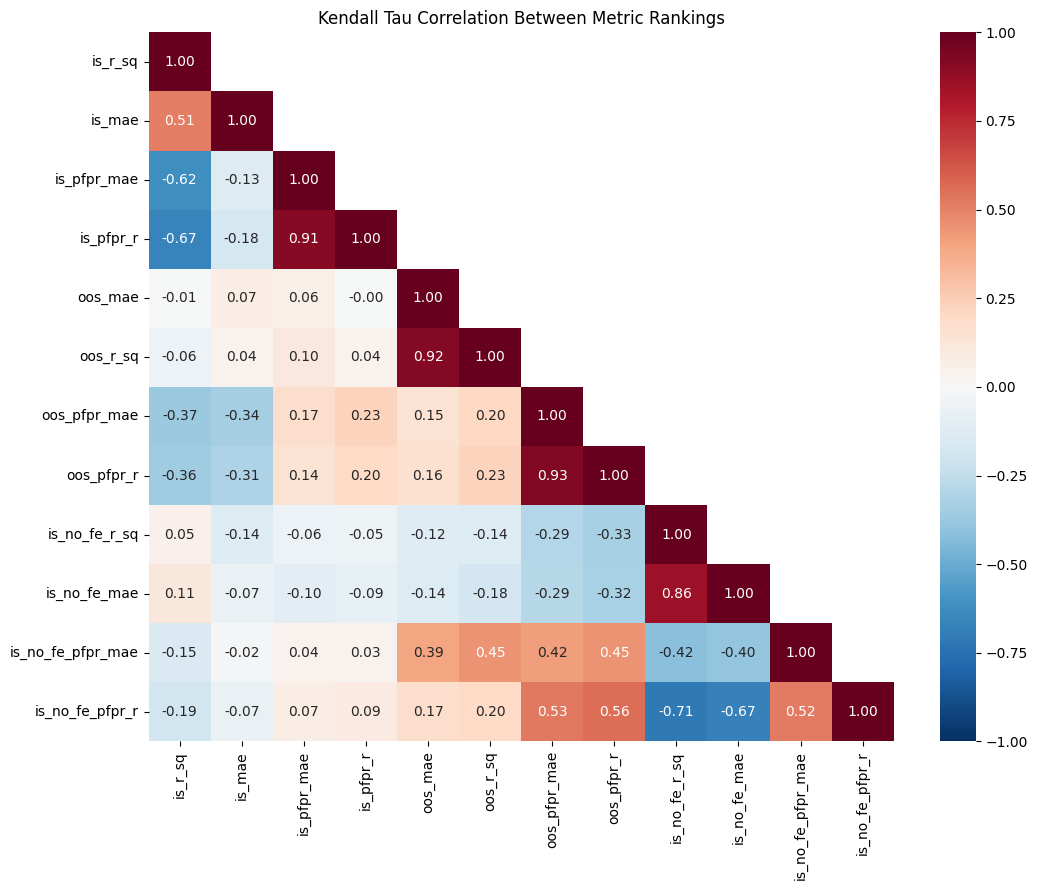


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.031
Pairs with negative correlation: 33
Low agreement. Flat top tier may be aggregation artifact (metric cancellation).


In [10]:
print(f'Kendall τ on {len(metric_df):,} tasks × {len(metrics_present)} metrics')
tau_df = kendall_tau_heatmap(metric_df, metrics_present, calib_present, figsize=(11, 9))
plt.show()

## Borda count

Sum-of-ranks across metrics, with an auto-detected elbow / cutpoint for
where the top tier ends.

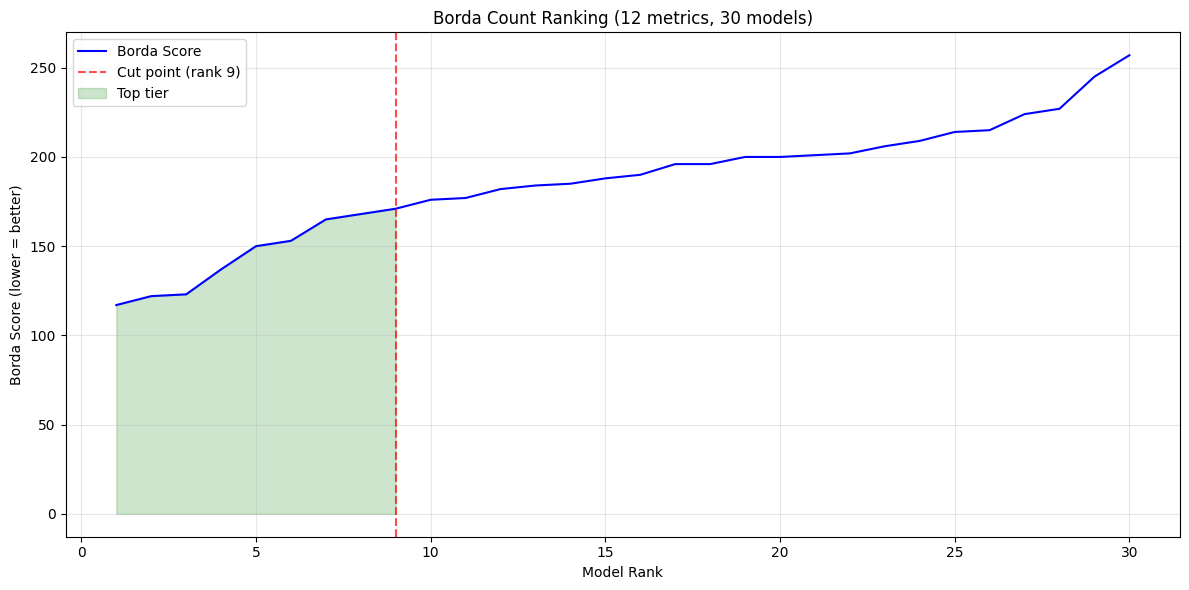


=== Borda Count Summary ===
Total models: 30
Metrics used: 12
Suggested cutpoint: rank 9 (top 9 models)
Top tier Borda range: 117.0 - 171.0
Bottom tier starts at: 176.0


,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,borda_score,borda_rank
0,1,1.412473e+06,1.413252e+06,2.322035e+06,0.818854,0.818854,2.847173,1.985712,5.615491,4.590519,0.295347,0.080750,0.034013,0.875502,0.178830,0.082469,0.255125,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688,117.0,1.0
1,22,1.411760e+06,1.412560e+06,2.316229e+06,0.819307,0.819307,2.843611,1.987352,5.622123,4.604915,0.293681,0.082202,0.034751,0.871073,0.179258,0.082843,0.208711,1.733683e+06,1.733761e+06,0.443798,0.443798,4.989033,4.038690,0.081088,0.362208,122.0,2.0
2,57,1.403598e+06,1.404434e+06,2.251107e+06,0.824388,0.824388,2.803351,1.985382,5.615492,4.590519,0.295347,0.096319,0.039815,0.831393,0.178830,0.082469,0.255126,1.735822e+06,1.735865e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688,123.0,3.0
3,162,1.395766e+06,1.396612e+06,2.190382e+06,0.829125,0.829125,2.765281,1.978343,5.621688,4.604527,0.293791,0.105627,0.043352,0.805193,0.179256,0.082839,0.208222,1.733661e+06,1.733739e+06,0.443841,0.443841,4.988837,4.038478,0.081084,0.361706,137.0,4.0
4,141,1.396043e+06,1.396867e+06,2.192532e+06,0.828957,0.828957,2.766638,1.978831,5.615492,4.590520,0.295347,0.105303,0.043206,0.806114,0.178830,0.082469,0.255126,1.735822e+06,1.735865e+06,0.439615,0.439615,5.007755,4.052992,0.081259,0.387689,150.0,5.0
5,15,1.412464e+06,1.413253e+06,2.321947e+06,0.818861,0.818861,2.847119,1.986328,5.639376,4.623043,0.289340,0.080848,0.034066,0.875177,0.179598,0.083149,0.198037,1.734571e+06,1.734636e+06,0.442067,0.442067,4.996788,4.048406,0.081259,0.370489,153.0,6.0
6,120,1.403543e+06,1.404336e+06,2.250736e+06,0.824417,0.824417,2.803120,1.995467,5.727673,4.667600,0.266912,0.098323,0.041139,0.829618,0.179444,0.082787,0.239054,1.733886e+06,1.733949e+06,0.443399,0.443399,4.990822,4.029089,0.081431,0.374492,165.0,7.0
7,8,1.412464e+06,1.413253e+06,2.321944e+06,0.818862,0.818862,2.847116,1.986318,5.645264,4.622946,0.287855,0.080847,0.034066,0.875182,0.179722,0.083108,0.191786,1.735650e+06,1.735702e+06,0.439957,0.439957,5.006227,4.054246,0.081301,0.383566,168.0,8.0
8,155,1.396233e+06,1.397039e+06,2.194011e+06,0.828842,0.828842,2.767571,1.979515,5.639233,4.622893,0.289376,0.105367,0.043223,0.805842,0.179589,0.083137,0.198621,1.734569e+06,1.734634e+06,0.442071,0.442071,4.996770,4.048392,0.081259,0.370458,171.0,9.0
9,92,1.403216e+06,1.404021e+06,2.248155e+06,0.824618,0.824618,2.801512,1.995046,5.740415,4.690847,0.263646,0.098614,0.041255,0.828844,0.179730,0.083056,0.195053,1.732056e+06,1.732145e+06,0.446953,0.446953,4.974864,4.024913,0.081261,0.342783,176.0,10.0


In [11]:
borda_df, borda_cutpoint = borda_rank(metric_df, metrics_present, calib_present)
borda_df.head(10)

## TOPSIS

Distance-to-ideal scoring with min-max normalisation (equal influence per
metric). `influence` reports per-metric separation power.

In [12]:
topsis_df, influence = topsis_rank(metric_df, metrics_present, calib_present, verbose=True)
topsis_df.head(10)


=== TOPSIS Ranking (normalize=minmax) ===
Models ranked: 30
Metrics used: 12

Top 10 by TOPSIS:
   topsis_rank  topsis_score   is_r_sq    is_mae  is_pfpr_mae  is_pfpr_r   oos_mae
0          1.0      0.614475  0.819307  1.987352     0.034751   0.871073  4.604915
1          2.0      0.600885  0.818854  1.985712     0.034013   0.875502  4.590519
2          3.0      0.576209  0.818861  1.986328     0.034066   0.875177  4.623043
3          4.0      0.572121  0.824388  1.985382     0.039815   0.831393  4.590519
4          5.0      0.568578  0.829125  1.978343     0.043352   0.805193  4.604527
5          6.0      0.557977  0.818862  1.986318     0.034066   0.875182  4.622946
6          7.0      0.557876  0.828957  1.978831     0.043206   0.806114  4.590520
7          8.0      0.526049  0.826386  1.963857     0.037161   0.850704  4.702661
8          9.0      0.524798  0.828842  1.979515     0.043223   0.805842  4.622893
9         10.0      0.512368  0.824417  1.995467     0.041139   0.829618 

,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,topsis_score,topsis_rank
0,22,1.411760e+06,1.412560e+06,2.316229e+06,0.819307,0.819307,2.843611,1.987352,5.622123,4.604915,0.293681,0.082202,0.034751,0.871073,0.179258,0.082843,0.208711,1.733683e+06,1.733761e+06,0.443798,0.443798,4.989033,4.038690,0.081088,0.362208,0.614475,1.0
1,1,1.412473e+06,1.413252e+06,2.322035e+06,0.818854,0.818854,2.847173,1.985712,5.615491,4.590519,0.295347,0.080750,0.034013,0.875502,0.178830,0.082469,0.255125,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688,0.600885,2.0
2,15,1.412464e+06,1.413253e+06,2.321947e+06,0.818861,0.818861,2.847119,1.986328,5.639376,4.623043,0.289340,0.080848,0.034066,0.875177,0.179598,0.083149,0.198037,1.734571e+06,1.734636e+06,0.442067,0.442067,4.996788,4.048406,0.081259,0.370489,0.576209,3.0
3,57,1.403598e+06,1.404434e+06,2.251107e+06,0.824388,0.824388,2.803351,1.985382,5.615492,4.590519,0.295347,0.096319,0.039815,0.831393,0.178830,0.082469,0.255126,1.735822e+06,1.735865e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688,0.572121,4.0
4,162,1.395766e+06,1.396612e+06,2.190382e+06,0.829125,0.829125,2.765281,1.978343,5.621688,4.604527,0.293791,0.105627,0.043352,0.805193,0.179256,0.082839,0.208222,1.733661e+06,1.733739e+06,0.443841,0.443841,4.988837,4.038478,0.081084,0.361706,0.568578,5.0
5,8,1.412464e+06,1.413253e+06,2.321944e+06,0.818862,0.818862,2.847116,1.986318,5.645264,4.622946,0.287855,0.080847,0.034066,0.875182,0.179722,0.083108,0.191786,1.735650e+06,1.735702e+06,0.439957,0.439957,5.006227,4.054246,0.081301,0.383566,0.557977,6.0
6,141,1.396043e+06,1.396867e+06,2.192532e+06,0.828957,0.828957,2.766638,1.978831,5.615492,4.590520,0.295347,0.105303,0.043206,0.806114,0.178830,0.082469,0.255126,1.735822e+06,1.735865e+06,0.439615,0.439615,5.007755,4.052992,0.081259,0.387689,0.557876,7.0
7,29,1.400311e+06,1.401100e+06,2.225497e+06,0.826386,0.826386,2.787359,1.963857,5.756651,4.702661,0.259475,0.089444,0.037161,0.850704,0.179761,0.083664,0.180550,1.735117e+06,1.735169e+06,0.440999,0.440999,5.001571,4.047076,0.081433,0.354626,0.526049,8.0
8,155,1.396233e+06,1.397039e+06,2.194011e+06,0.828842,0.828842,2.767571,1.979515,5.639233,4.622893,0.289376,0.105367,0.043223,0.805842,0.179589,0.083137,0.198621,1.734569e+06,1.734634e+06,0.442071,0.442071,4.996770,4.048392,0.081259,0.370458,0.524798,9.0
9,120,1.403543e+06,1.404336e+06,2.250736e+06,0.824417,0.824417,2.803120,1.995467,5.727673,4.667600,0.266912,0.098323,0.041139,0.829618,0.179444,0.082787,0.239054,1.733886e+06,1.733949e+06,0.443399,0.443399,4.990822,4.029089,0.081431,0.374492,0.512368,10.0


## Pareto frontier

Non-dominated set: tasks that no other task strictly beats on every
metric. Large frontiers mean genuine trade-offs across metrics; small
frontiers mean a few tasks dominate the field.

In [13]:
pareto_df = pareto_frontier(metric_df, metrics_present, calib_present)
print(f'\nFrontier size: {len(pareto_df):,} / {len(metric_df):,} '
      f'({100 * len(pareto_df) / len(metric_df):.1f}%)')
pareto_df.head(10)


=== Pareto Frontier ===
Total models: 30
Non-dominated: 30 (100.0%)
Dominated: 0

Frontier size: 30 / 30 (100.0%)


,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r
0,1,1.412473e+06,1.413252e+06,2.322035e+06,0.818854,0.818854,2.847173,1.985712,5.615491,4.590519,0.295347,0.080750,0.034013,0.875502,0.178830,0.082469,0.255125,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688
7,8,1.412464e+06,1.413253e+06,2.321944e+06,0.818862,0.818862,2.847116,1.986318,5.645264,4.622946,0.287855,0.080847,0.034066,0.875182,0.179722,0.083108,0.191786,1.735650e+06,1.735702e+06,0.439957,0.439957,5.006227,4.054246,0.081301,0.383566
14,15,1.412464e+06,1.413253e+06,2.321947e+06,0.818861,0.818861,2.847119,1.986328,5.639376,4.623043,0.289340,0.080848,0.034066,0.875177,0.179598,0.083149,0.198037,1.734571e+06,1.734636e+06,0.442067,0.442067,4.996788,4.048406,0.081259,0.370489
21,22,1.411760e+06,1.412560e+06,2.316229e+06,0.819307,0.819307,2.843611,1.987352,5.622123,4.604915,0.293681,0.082202,0.034751,0.871073,0.179258,0.082843,0.208711,1.733683e+06,1.733761e+06,0.443798,0.443798,4.989033,4.038690,0.081088,0.362208
28,29,1.400311e+06,1.401100e+06,2.225497e+06,0.826386,0.826386,2.787359,1.963857,5.756651,4.702661,0.259475,0.089444,0.037161,0.850704,0.179761,0.083664,0.180550,1.735117e+06,1.735169e+06,0.440999,0.440999,5.001571,4.047076,0.081433,0.354626
35,36,1.396136e+06,1.396954e+06,2.193250e+06,0.828901,0.828901,2.767091,1.969550,5.672807,4.642897,0.280889,0.097640,0.040594,0.829576,0.180941,0.084507,0.133571,1.734984e+06,1.735080e+06,0.441274,0.441274,5.000338,4.045033,0.081502,0.341017
42,43,1.396915e+06,1.397718e+06,2.199245e+06,0.828434,0.828434,2.770870,1.969926,5.749756,4.702207,0.261248,0.097101,0.040197,0.830250,0.180193,0.083968,0.165086,1.735822e+06,1.735865e+06,0.439615,0.439615,5.007755,4.052992,0.081259,0.387689
49,50,1.405760e+06,1.406548e+06,2.268237e+06,0.823051,0.823051,2.813997,1.989714,5.758112,4.706454,0.259099,0.092985,0.038846,0.840931,0.179186,0.082734,0.244991,1.735302e+06,1.735355e+06,0.440636,0.440636,5.003194,4.051878,0.081394,0.381182
56,57,1.403598e+06,1.404434e+06,2.251107e+06,0.824388,0.824388,2.803351,1.985382,5.615492,4.590519,0.295347,0.096319,0.039815,0.831393,0.178830,0.082469,0.255126,1.735822e+06,1.735865e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688
63,64,1.405760e+06,1.406548e+06,2.268237e+06,0.823051,0.823051,2.813997,1.989714,5.835481,4.764368,0.239055,0.092985,0.038846,0.840931,0.179158,0.082670,0.249322,1.735380e+06,1.735433e+06,0.440485,0.440485,5.003869,4.052104,0.081358,0.384280


## Pairwise dominance

For each pair (A, B), A beats B if A wins on a majority of metrics.
`dominance_count` = how many tasks each task beats.

In [6]:
dominance_df = pairwise_dominance_summary(metric_df, metrics_present, calib_present)
dominance_df.head(10)

NameError: name 'metric_df' is not defined

In [15]:
df.shape

(210, 52)

## Winners by method

Side-by-side comparison of the top pick from each method on a shared
metric set. Pareto frontier has no canonical order — `pareto_first` is
the first row of the frontier (df order), not a "best" frontier member.

In [16]:
df = df.merge(dominance_df[['task_id', 'dominance_rank']], on='task_id')
df = df.merge(topsis_df[['task_id', 'topsis_rank']], on='task_id')
df = df.merge(borda_df[['task_id', 'borda_rank']], on='task_id')

In [17]:
winners = {
    'borda':              borda_df.iloc[0],
    'topsis':             topsis_df.iloc[0],
    'pareto_first':       pareto_df.iloc[0],
    'pairwise_dominance': dominance_df.iloc[0],
}

show_cols = [c for c in CONFIG_COLS if c in metric_df.columns] +  [k for k in metrics_present.keys()] + ['is_aic', 'is_bic', 'is_dev_expl', 
    'oos_rmse', 'oos_mae']
show_cols = [c for c in show_cols if c in metric_df.columns]

winners_df = pd.DataFrame({k: w[show_cols] for k, w in winners.items()}).T
winners_df['selection_method'] = winners_df.index   # capture here
winners_df = winners_df.merge(dominance_df[['task_id', 'dominance_rank']], on='task_id')
winners_df = winners_df.merge(topsis_df[['task_id', 'topsis_rank']], on='task_id')
winners_df = winners_df.merge(borda_df[['task_id', 'borda_rank']], on='task_id')
winners_df = winners_df.set_index('selection_method')
# make the rank columns more visible by putting them up front:
rank_cols = ['borda_rank', 'topsis_rank', 'dominance_rank']
other_cols = [c for c in winners_df.columns if c not in rank_cols]
winners_df = winners_df[rank_cols + other_cols]
winners_df

,borda_rank,topsis_rank,dominance_rank,task_id,is_r_sq,is_mae,is_pfpr_mae,is_pfpr_r,oos_mae,oos_mae,oos_r_sq,oos_pfpr_mae,oos_pfpr_r,is_no_fe_r_sq,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,is_aic,is_bic,is_dev_expl,oos_rmse,oos_mae,oos_mae
selection_method,,,,,,,,,,,,,,,,,,,,,,,
borda,1.0,2.0,1.0,1.0,0.818854,1.985712,0.034013,0.875502,4.590519,4.590519,0.295347,0.082469,0.255125,0.439616,4.05299,0.081259,0.387688,1.412473e+06,1.413252e+06,0.818854,5.615491,4.590519,4.590519
topsis,2.0,1.0,3.0,22.0,0.819307,1.987352,0.034751,0.871073,4.604915,4.604915,0.293681,0.082843,0.208711,0.443798,4.03869,0.081088,0.362208,1.411760e+06,1.412560e+06,0.819307,5.622123,4.604915,4.604915
pareto_first,1.0,2.0,1.0,1.0,0.818854,1.985712,0.034013,0.875502,4.590519,4.590519,0.295347,0.082469,0.255125,0.439616,4.05299,0.081259,0.387688,1.412473e+06,1.413252e+06,0.818854,5.615491,4.590519,4.590519
pairwise_dominance,1.0,2.0,1.0,1.0,0.818854,1.985712,0.034013,0.875502,4.590519,4.590519,0.295347,0.082469,0.255125,0.439616,4.05299,0.081259,0.387688,1.412473e+06,1.413252e+06,0.818854,5.615491,4.590519,4.590519


In [18]:
borda_df

,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,borda_score,borda_rank
0,1,1.412473e+06,1.413252e+06,2.322035e+06,0.818854,0.818854,2.847173,1.985712,5.615491,4.590519,0.295347,0.080750,0.034013,0.875502,0.178830,0.082469,0.255125,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688,117.0,1.0
1,22,1.411760e+06,1.412560e+06,2.316229e+06,0.819307,0.819307,2.843611,1.987352,5.622123,4.604915,0.293681,0.082202,0.034751,0.871073,0.179258,0.082843,0.208711,1.733683e+06,1.733761e+06,0.443798,0.443798,4.989033,4.038690,0.081088,0.362208,122.0,2.0
2,57,1.403598e+06,1.404434e+06,2.251107e+06,0.824388,0.824388,2.803351,1.985382,5.615492,4.590519,0.295347,0.096319,0.039815,0.831393,0.178830,0.082469,0.255126,1.735822e+06,1.735865e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688,123.0,3.0
3,162,1.395766e+06,1.396612e+06,2.190382e+06,0.829125,0.829125,2.765281,1.978343,5.621688,4.604527,0.293791,0.105627,0.043352,0.805193,0.179256,0.082839,0.208222,1.733661e+06,1.733739e+06,0.443841,0.443841,4.988837,4.038478,0.081084,0.361706,137.0,4.0
4,141,1.396043e+06,1.396867e+06,2.192532e+06,0.828957,0.828957,2.766638,1.978831,5.615492,4.590520,0.295347,0.105303,0.043206,0.806114,0.178830,0.082469,0.255126,1.735822e+06,1.735865e+06,0.439615,0.439615,5.007755,4.052992,0.081259,0.387689,150.0,5.0
5,15,1.412464e+06,1.413253e+06,2.321947e+06,0.818861,0.818861,2.847119,1.986328,5.639376,4.623043,0.289340,0.080848,0.034066,0.875177,0.179598,0.083149,0.198037,1.734571e+06,1.734636e+06,0.442067,0.442067,4.996788,4.048406,0.081259,0.370489,153.0,6.0
6,120,1.403543e+06,1.404336e+06,2.250736e+06,0.824417,0.824417,2.803120,1.995467,5.727673,4.667600,0.266912,0.098323,0.041139,0.829618,0.179444,0.082787,0.239054,1.733886e+06,1.733949e+06,0.443399,0.443399,4.990822,4.029089,0.081431,0.374492,165.0,7.0
7,8,1.412464e+06,1.413253e+06,2.321944e+06,0.818862,0.818862,2.847116,1.986318,5.645264,4.622946,0.287855,0.080847,0.034066,0.875182,0.179722,0.083108,0.191786,1.735650e+06,1.735702e+06,0.439957,0.439957,5.006227,4.054246,0.081301,0.383566,168.0,8.0
8,155,1.396233e+06,1.397039e+06,2.194011e+06,0.828842,0.828842,2.767571,1.979515,5.639233,4.622893,0.289376,0.105367,0.043223,0.805842,0.179589,0.083137,0.198621,1.734569e+06,1.734634e+06,0.442071,0.442071,4.996770,4.048392,0.081259,0.370458,171.0,9.0
9,92,1.403216e+06,1.404021e+06,2.248155e+06,0.824618,0.824618,2.801512,1.995046,5.740415,4.690847,0.263646,0.098614,0.041255,0.828844,0.179730,0.083056,0.195053,1.732056e+06,1.732145e+06,0.446953,0.446953,4.974864,4.024913,0.081261,0.342783,176.0,10.0


In [19]:
task_id = 2
print(f'Borda rank: {borda_df[borda_df['task_id'] == task_id]['borda_rank'].values[0]}')
print(f'Topsis rank: {topsis_df[topsis_df['task_id'] == task_id]['topsis_rank'].values[0]}')
print(f'Dominance rank: {dominance_df[dominance_df['task_id'] == task_id]['dominance_rank'].values[0]}')


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
# find all task ids that have people_flood_days and humidity in the formula text
task_ids = df[
    df['formula_text'].str.contains('people_flood_days')
]['task_id'].tolist()
df[df['task_id'].isin(task_ids)][show_cols + [c for c in df.columns if 'rank' in c]].sort_values('topsis_rank')

,task_id,is_r_sq,is_mae,is_pfpr_mae,is_pfpr_r,oos_mae,oos_r_sq,oos_pfpr_mae,oos_pfpr_r,is_no_fe_r_sq,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,is_aic,is_bic,is_dev_expl,oos_rmse,oos_mae,dominance_rank,topsis_rank,borda_rank
22,23,0.819459,1.985761,0.034602,0.872796,4.461060,0.346840,0.084297,0.153367,0.476323,3.937655,0.081372,0.309261,1.411521e+06,1.412326e+06,0.819459,5.406422,4.461060,3.0,2.0,2.0
8,9,0.819013,1.984643,0.033922,0.876788,4.474250,0.342891,0.084315,0.152739,0.473932,3.947739,0.081459,0.310493,1.412226e+06,1.413021e+06,0.819013,5.422741,4.474250,8.0,4.0,4.0
15,16,0.819029,1.985181,0.033980,0.876433,4.475145,0.343658,0.084516,0.146462,0.473932,3.947641,0.081458,0.310486,1.412203e+06,1.413011e+06,0.819029,5.419573,4.475145,9.0,5.0,6.0
24,25,0.819350,1.986655,0.034788,0.870540,4.433074,0.352967,0.085149,0.126942,0.476981,3.925909,0.081646,0.248299,1.411694e+06,1.412505e+06,0.819350,5.381001,4.433074,37.5,9.0,28.0
148,149,0.828999,1.977469,0.043157,0.806111,4.474251,0.342891,0.084315,0.152740,0.473932,3.947743,0.081459,0.310494,1.395977e+06,1.396822e+06,0.828999,5.422741,4.474251,29.0,11.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,89,0.821546,2.017879,0.042262,0.818919,4.709344,0.259007,0.083337,0.183560,0.444147,4.038847,0.081553,0.341766,1.408191e+06,1.409000e+06,0.821546,5.758469,4.709344,201.0,197.0,199.0
81,82,0.821571,2.017376,0.042217,0.819425,4.710399,0.257057,0.083368,0.172691,0.442889,4.041653,0.081548,0.354333,1.408153e+06,1.408973e+06,0.821571,5.766043,4.710399,203.5,199.0,202.5
96,97,0.824979,1.991100,0.041265,0.828113,4.712946,0.275849,0.085861,0.105341,0.471484,3.969829,0.082408,0.255121,1.402628e+06,1.403444e+06,0.824979,5.692653,4.712946,192.0,204.0,205.0
82,83,0.824747,1.991570,0.041101,0.829527,4.736023,0.268215,0.086113,0.098547,0.467794,3.985631,0.082639,0.254686,1.403006e+06,1.403810e+06,0.824747,5.722577,4.736023,196.5,209.0,206.0


In [ ]:
# find all task ids that don't have urban in the formula text
task_ids = df[
    ~df['formula_text'].str.contains('urban')
]['task_id'].tolist()
df[df['task_id'].isin(task_ids)][show_cols + [c for c in df.columns if 'rank' in c]].sort_values('topsis_rank')

,task_id,is_r_sq,is_mae,is_pfpr_mae,is_pfpr_r,oos_mae,oos_r_sq,oos_pfpr_mae,oos_pfpr_r,is_no_fe_r_sq,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,is_aic,is_bic,is_dev_expl,oos_rmse,oos_mae,dominance_rank,topsis_rank,borda_rank
0,1,0.818854,1.985712,0.034013,0.875502,4.590519,0.295347,0.082469,0.255125,0.439616,4.052990,0.081259,0.387688,1.412473e+06,1.413252e+06,0.818854,5.615491,4.590519,7.0,17.0,11.0
21,22,0.819307,1.987352,0.034751,0.871073,4.604915,0.293681,0.082843,0.208711,0.443798,4.038690,0.081088,0.362208,1.411760e+06,1.412560e+06,0.819307,5.622123,4.604915,19.5,24.0,14.0
56,57,0.824388,1.985382,0.039815,0.831393,4.590519,0.295347,0.082469,0.255126,0.439616,4.052990,0.081259,0.387688,1.403598e+06,1.404434e+06,0.824388,5.615492,4.590519,14.0,39.0,18.0
14,15,0.818861,1.986328,0.034066,0.875177,4.623043,0.289340,0.083149,0.198037,0.442067,4.048406,0.081259,0.370489,1.412464e+06,1.413253e+06,0.818861,5.639376,4.623043,42.5,40.0,38.5
7,8,0.818862,1.986318,0.034066,0.875182,4.622946,0.287855,0.083108,0.191786,0.439957,4.054246,0.081301,0.383566,1.412464e+06,1.413253e+06,0.818862,5.645264,4.622946,45.0,46.0,53.5
140,141,0.828957,1.978831,0.043206,0.806114,4.590520,0.295347,0.082469,0.255126,0.439615,4.052992,0.081259,0.387689,1.396043e+06,1.396867e+06,0.828957,5.615492,4.590520,35.0,53.0,38.5
161,162,0.829125,1.978343,0.043352,0.805193,4.604527,0.293791,0.082839,0.208222,0.443841,4.038478,0.081084,0.361706,1.395766e+06,1.396612e+06,0.829125,5.621688,4.604527,35.0,64.0,31.0
28,29,0.826386,1.963857,0.037161,0.850704,4.702661,0.259475,0.083664,0.180550,0.440999,4.047076,0.081433,0.354626,1.400311e+06,1.401100e+06,0.826386,5.756651,4.702661,29.0,66.0,51.0
154,155,0.828842,1.979515,0.043223,0.805842,4.622893,0.289376,0.083137,0.198621,0.442071,4.048392,0.081259,0.370458,1.396233e+06,1.397039e+06,0.828842,5.639233,4.622893,74.0,85.0,68.0
147,148,0.828963,1.978306,0.043160,0.806539,4.622948,0.287855,0.083108,0.191787,0.439957,4.054249,0.081301,0.383567,1.396036e+06,1.396871e+06,0.828963,5.645264,4.622948,100.0,89.0,97.0
